Part 1: Data Import & Preparation

In [ ]:
install.packages(c("tidyverse","arrow","robustbase","broom","modelr"))

library(tidyverse)
library(arrow)
library(robustbase)
library(broom)
library(modelr)


months <- sprintf("%02d", 1:3)
base_url <- "https://d37ci6vzurychx.cloudfront.net/trip-data/"

taxi_list <- lapply(months, function(m) {
  read_parquet(paste0(base_url, "yellow_tripdata_2023-", m, ".parquet"))
})

taxi <- bind_rows(taxi_list)

glimpse(taxi)

taxi_clean <- taxi %>%
  filter(trip_distance > 0,
         total_amount > 0)


taxi_clean <- taxi_clean %>%
  mutate(
    pickup_datetime  = as.POSIXct(tpep_pickup_datetime),
    dropoff_datetime = as.POSIXct(tpep_dropoff_datetime),

    trip_duration_minutes = as.numeric(
      difftime(dropoff_datetime,
               pickup_datetime,
               units = "mins")
    ),

    fare_per_mile = total_amount / trip_distance,

    month = factor(format(pickup_datetime, "%m"),
                   levels = sprintf("%02d", 1:12))
  ) %>%
  filter(trip_duration_minutes > 0)


data_model <- taxi_clean %>%
  select(total_amount,
         trip_distance,
         trip_duration_minutes,
         fare_per_mile)

summary(data_model)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘assertthat’


Warning message in install.packages(c("tidyverse", "arrow", "robustbase", "broom", :
“installation of package ‘robustbase’ had non-zero exit status”

Attaching package: ‘arrow’


The following object is masked from ‘package:lubridate’:

    duration


The following object is masked from ‘package:utils’:

    timestamp




Rows: 9,384,487
Columns: 20
$ VendorID              <int> 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, …
$ tpep_pickup_datetime  <dttm> 2023-01-01 00:32:10, 2023-01-01 00:55:08, 2023-…
$ tpep_dropoff_datetime <dttm> 2023-01-01 00:40:36, 2023-01-01 01:01:27, 2023-…
$ passenger_count       <dbl> 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 4, 1, 2, 1, 1, …
$ trip_distance         <dbl> 0.97, 1.10, 2.51, 1.90, 1.43, 1.84, 1.66, 11.70,…
$ RatecodeID            <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ store_and_fwd_flag    <chr> "N", "N", "N", "N", "N", "N", "N", "N", "N", "N"…
$ PULocationID          <int> 161, 43, 48, 138, 107, 161, 239, 142, 164, 141, …
$ DOLocationID          <int> 141, 237, 238, 7, 79, 137, 143, 200, 236, 107, 6…
$ payment_type          <int> 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, …
$ fare_amount           <dbl> 9.3, 7.9, 14.9, 12.1, 11.4, 12.8, 12.1, 45.7, 17…
$ extra                 <dbl> 1.00, 1.00, 1.00, 7.25, 1.00, 1.00, 1.00, 1.00, …
$ mta_tax   

  total_amount     trip_distance      trip_duration_minutes fare_per_mile     
 Min.   :   0.11   Min.   :1.00e-02   Min.   :   0.0167     Min.   :    0.00  
 1st Qu.:  15.70   1st Qu.:1.10e+00   1st Qu.:   7.3833     1st Qu.:    8.08  
 Median :  20.50   Median :1.80e+00   Median :  11.9167     Median :   11.04  
 Mean   :  27.64   Mean   :3.93e+00   Mean   :  16.3192     Mean   :   15.89  
 3rd Qu.:  29.04   3rd Qu.:3.39e+00   3rd Qu.:  18.9833     3rd Qu.:   14.90  
 Max.   :1169.40   Max.   :3.35e+05   Max.   :7053.6167     Max.   :48420.00  

In [ ]:
set.seed(123)
data_model <- data_model %>% sample_n(100000)

PART 2: CLASSICAL LINEAR REGRESSION


Call:
lm(formula = total_amount ~ trip_distance, data = data_model)

Residuals:
    Min      1Q  Median      3Q     Max 
-400.23  -11.82   -7.11    1.37  472.44 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   27.435550   0.067712  405.18   <2e-16 ***
trip_distance  0.048549   0.001581   30.72   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 21.33 on 99998 degrees of freedom
Multiple R-squared:  0.009347,	Adjusted R-squared:  0.009337 
F-statistic: 943.5 on 1 and 99998 DF,  p-value: < 2.2e-16


[1] 0.009346773

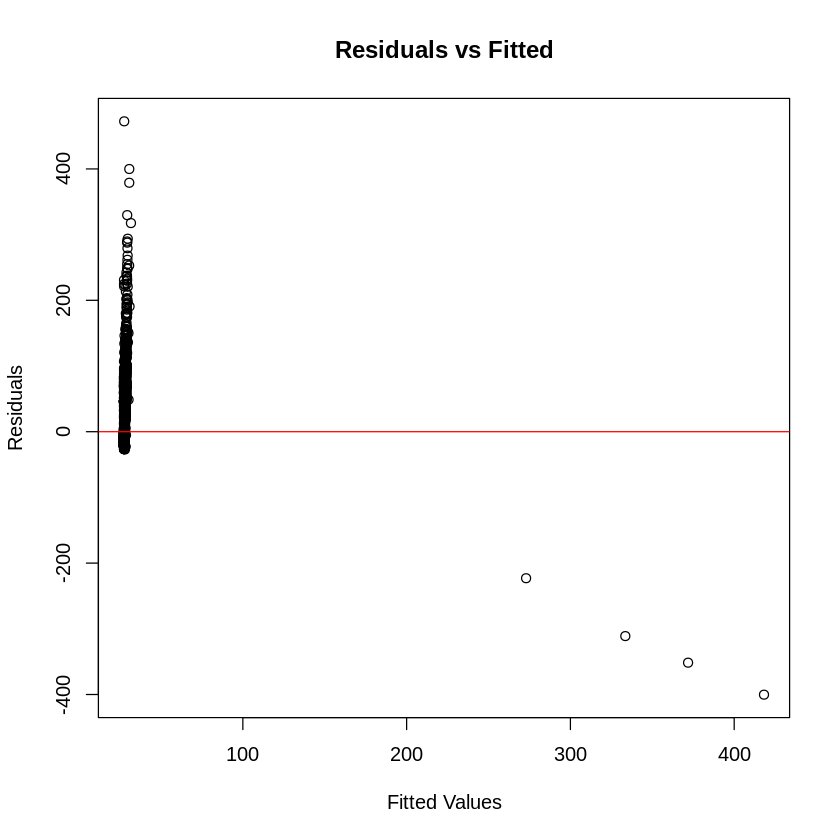

In [ ]:
lm_model <- lm(total_amount ~ trip_distance, data = data_model)

summary(lm_model)

summary(lm_model)$r.squared

plot(lm_model$fitted.values,
     lm_model$residuals,
     xlab="Fitted Values",
     ylab="Residuals",
     main="Residuals vs Fitted")
abline(h=0, col="red")

Interpretation

Coefficient Estimates: The fitted model is ŷ = 27.44 + 0.0485(trip_distance), meaning both intercept and slope are statistically significant (p < 0.001).

Slope Interpretation: For every 1-mile increase in trip distance, the total fare increases by about $0.0485 on average.

R²: The R² value of 0.0093 means trip distance explains only 0.93% of the variation in total fare, indicating very weak explanatory power.

Linearity: The extremely low R² suggests the relationship between distance and fare is not adequately captured by a simple linear model.

Heteroskedasticity: The large spread of residuals indicates non-constant variance, meaning variability increases for longer trips.

PART 3: FLEXIBLE MODELING

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


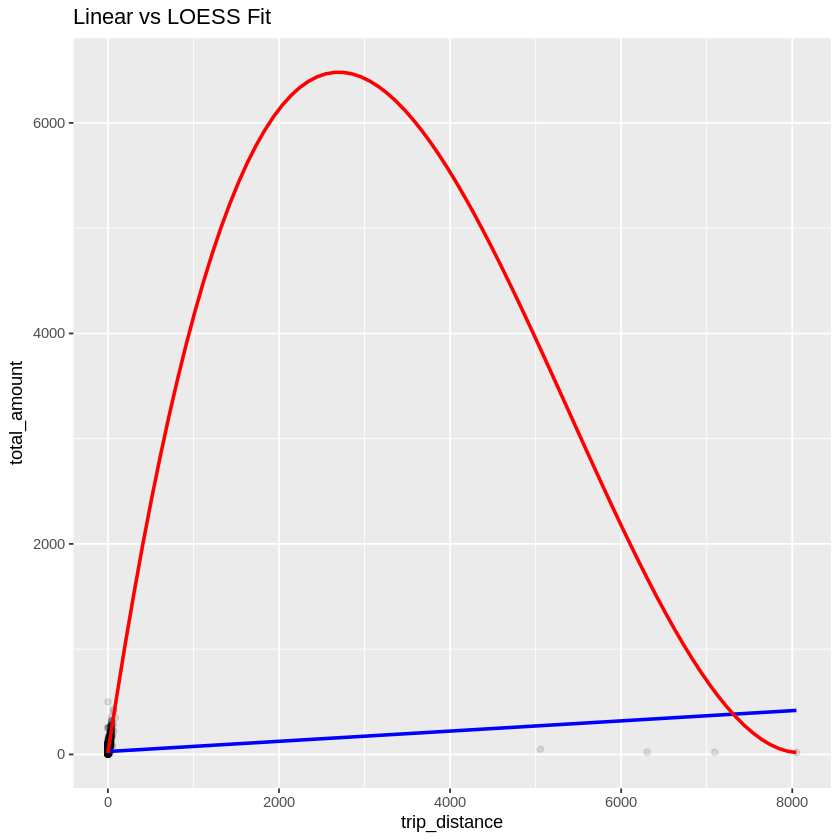

In [ ]:
loess_model <- loess(total_amount ~ trip_distance,
                     data = data_model,
                     span = 0.3)

ggplot(data_model, aes(x=trip_distance, y=total_amount)) +
  geom_point(alpha=0.1) +
  geom_smooth(method="lm", se=FALSE, color="blue") +
  geom_smooth(method="loess", se=FALSE, color="red") +
  labs(title="Linear vs LOESS Fit")

In [ ]:
rmse_lm <- sqrt(mean(residuals(lm_model)^2))

loess_pred <- predict(loess_model, data_model)
rmse_loess <- sqrt(mean((data_model$total_amount - loess_pred)^2))

rmse_lm
rmse_loess

[1] 21.33337

[1] 10.09118

PART 4: ROBUST REGRESSION & INFLUENCE

1. Detect influential observations

In [ ]:
cooks <- cooks.distance(lm_model)

top10_index <- order(cooks, decreasing=TRUE)[1:10]

influential_trips <- data_model[top10_index, ]
influential_trips

total_amount,trip_distance,trip_duration_minutes,fare_per_mile
<dbl>,<dbl>,<dbl>,<dbl>
17.97,8048.97,6.00000,2.232584e-03
20.31,7094.16,18.00000,2.862918e-03
22.46,6304.78,17.00000,3.562376e-03
49.95,5056.82,30.75000,9.877749e-03
430.55,66.42,81.93333,6.482234e+00
349.25,87.42,132.28333,3.995081e+00
409.61,66.07,88.30000,6.199637e+00
500.00,2.50,7.05000,2.000000e+02
283.55,64.75,118.08333,4.379151e+00


2. List 10 most influential trips.

In [ ]:
robust_model <- lmrob(total_amount ~ trip_distance,
                      data = data_model)

summary(robust_model)


Call:
lmrob(formula = total_amount ~ trip_distance, data = data_model)
 \--> method = "MM"
Residuals:
       Min         1Q     Median         3Q        Max 
-3.849e+04 -2.260e+00 -1.977e-01  2.371e+00  4.770e+02 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)   11.00788    0.03485   315.8   <2e-16 ***
trip_distance  4.78272    0.01920   249.1   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Robust residual standard error: 3.409 
Multiple R-squared:  0.9495,	Adjusted R-squared:  0.9495 
Convergence in 49 IRWLS iterations

Robustness weights: 
 2877 observations c(3,4,30,54,76,96,129,177,214,245,326,342,509,534,544,545,558,629,644,762,802,816,889,953,977,1012,1047,1073,1079,1088,1089,1125,1134,1136,1219,1263,1267,1346,1419,1425,1463,1468,1491,1556,1577,1612,1631,1639,1710,1719,1724,1788,1852,1853,1872,1881,1882,1886,1944,2002,2028,2030,2058,2059,2062,2118,2133,2326,2376,2414,2427,2429,2487,2568,2598,2611,2659,2660,2732,

3. Compare Coefficients

In [ ]:
coef(lm_model)
coef(robust_model)

ERROR: Error: object 'lm_model' not found


4. Compare Predictions at High Distance

In [ ]:
new_data <- data.frame(trip_distance = c(20, 30, 40))

predict(lm_model, new_data)
predict(robust_model, new_data)

ERROR: Error: object 'lm_model' not found


PART 5: SEASONAL COMPARISON

1. Create Quarter Variable

In [ ]:
taxi_clean <- taxi_clean %>%
  mutate(
    month_num = as.numeric(as.character(month)),
    quarter = case_when(
      month_num %in% 1:3  ~ "Q1",
      month_num %in% 4:6  ~ "Q2",
      month_num %in% 7:9  ~ "Q3",
      TRUE ~ "Q4"
    )
  )

taxi_clean$quarter <- factor(taxi_clean$quarter)

ERROR: Error in taxi_clean %>% mutate(month_num = as.numeric(as.character(month)), : could not find function "%>%"


2. Fit Separate Regressions

In [ ]:
quarter_models <- taxi_clean %>%
  group_by(quarter) %>%
  do(model = lm(total_amount ~ trip_distance, data = .))

quarter_models

ERROR: Error in taxi_clean %>% group_by(quarter) %>% do(model = lm(total_amount ~ : could not find function "%>%"


In [ ]:
quarter_models %>%
  mutate(tidy = map(model, tidy)) %>%
  unnest(tidy)

ERROR: Error in quarter_models %>% mutate(tidy = map(model, tidy)) %>% unnest(tidy): could not find function "%>%"


3. Plot Lines Together

In [ ]:
ggplot(taxi_clean, aes(x=trip_distance, y=total_amount, color=quarter)) +
  geom_smooth(method="lm", se=FALSE) +
  labs(title="Seasonal Comparison of Slopes")

ERROR: Error in ggplot(taxi_clean, aes(x = trip_distance, y = total_amount, color = quarter)): could not find function "ggplot"


PART 6: REFLECTION

Linear modeling becomes inadequate when relationships are nonlinear, when variance is not constant, or when extreme values distort estimates. In large urban transportation datasets, pricing structures often include base fares, surcharges, and dynamic pricing, which produce curved patterns rather than a strictly linear relationship between distance and total amount. Flexible regression methods such as LOESS allow the data to determine the shape of the relationship without assuming linearity, often resulting in lower prediction error. However, flexible models may overfit if not carefully tuned. Outliers are common in large datasets due to data entry errors, unusually long trips, or surge pricing. Ordinary Least Squares regression is highly sensitive to these extreme observations, which can distort coefficients and predictions. Robust regression methods reduce the influence of outliers, producing more stable and reliable estimates. Therefore, combining classical, flexible, and robust approaches provides a more comprehensive understanding of real-world transportation pricing behavior.